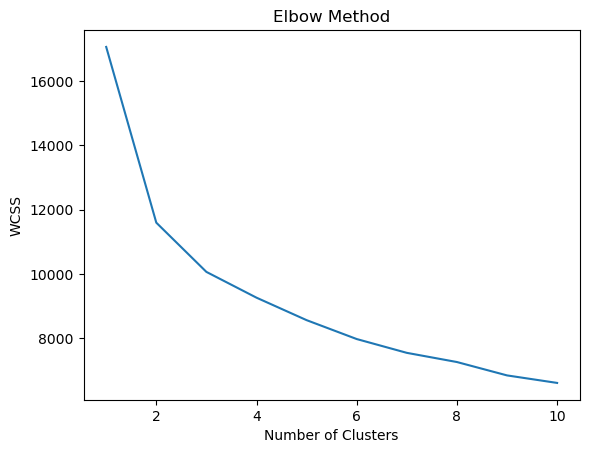

Breast Cancer KMeans clusters: [0 1 2 3]
Insurance KMeans clusters: [0 1 2]
Breast Cancer MeanShift clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Insurance MeanShift clusters: [0]
Breast Cancer DBSCAN clusters: [-1  0]


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MeanShift, DBSCAN
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Load Insurance dataset
df_ins = pd.read_csv("insurance.csv")

# Preprocessing Insurance dataset
df_ins = pd.get_dummies(df_ins, drop_first=True)
df_ins = df_ins.dropna()

# Scaling
scaler = StandardScaler()
X_cancer = scaler.fit_transform(df_cancer)
X_ins = scaler.fit_transform(df_ins)

# Elbow Method for Breast Cancer dataset
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_cancer)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# KMeans
kmeans_cancer = KMeans(n_clusters=4, random_state=42, n_init=10)
cancer_clusters = kmeans_cancer.fit_predict(X_cancer)

kmeans_ins = KMeans(n_clusters=3, random_state=42, n_init=10)
ins_clusters = kmeans_ins.fit_predict(X_ins)

# MeanShift
meanshift_cancer = MeanShift()
cancer_ms = meanshift_cancer.fit_predict(X_cancer)

meanshift_ins = MeanShift()
ins_ms = meanshift_ins.fit_predict(X_ins)

# DBSCAN on Breast Cancer dataset
dbscan = DBSCAN(eps=1.5, min_samples=5)
cancer_db = dbscan.fit_predict(X_cancer)

print("Breast Cancer KMeans clusters:", np.unique(cancer_clusters))
print("Insurance KMeans clusters:", np.unique(ins_clusters))
print("Breast Cancer MeanShift clusters:", np.unique(cancer_ms))
print("Insurance MeanShift clusters:", np.unique(ins_ms))
print("Breast Cancer DBSCAN clusters:", np.unique(cancer_db))